# Hyperparameter tuning over (model × dataset × fold) grid

Bayesian-Optimization search over PyLDL neural-net models. Each
(model, dataset, fold) job runs a complete BO search on one worker;
multiple jobs run concurrently — one per GPU when GPUs are visible, or
a small number of CPU workers otherwise (see `helpers.auto_pool_config`).

Each trial trains to convergence (early stopping) and is repeated 3
times (`executions_per_trial=3`) so the BO surrogate sees a noise-
averaged objective.

Best HPs + `val_kl_divergence` are written to
`results/<model>/<dataset>/fold_<fold>.txt` via `helpers.write_results`.

In [1]:
import sys
print(sys.executable)
print(sys.version)
print(sys.prefix)


/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v4/Compiler/gcccore/python/3.12.4/bin/python
3.12.4 (main, Jun 12 2024, 16:22:31) [GCC 13.3.0]
/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v4/Compiler/gcccore/python/3.12.4


In [2]:
import pyldl
print(pyldl.__file__)



/project/6004619/dcs01/PyLDL/pyldl/__init__.py


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import importlib
import sys
from concurrent.futures import as_completed
from pathlib import Path

import pandas as pd

_here = Path.cwd() if (Path.cwd() / 'helpers.py').exists() else Path.cwd() / 'bedl_experiments'
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

import pyldl.utils
import pyldl.algorithms
importlib.reload(pyldl.utils)
importlib.reload(pyldl.algorithms)

import helpers, hypertuner
importlib.reload(helpers)
importlib.reload(hypertuner)
from helpers import create_executer, read_results, load_data_fold, load_best_model, fit_best_model, plot_history
from hypertuner import run_search

E0000 00:00:1777668744.457767 3270018 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777668744.968492 3270018 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777668746.916105 3270018 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777668746.916177 3270018 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777668746.916180 3270018 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777668746.916182 3270018 computation_placer.cc:177] computation placer already registered. Please check linka

## Configure the search grid

In [4]:
MODELS   = ['BEDL', 'BEDL_BAYES', 'EDL', 'EDL_BAYES']
DATASETS = ['SJAFFE']
FOLDS    = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

MAX_TRIALS           = 12
EXECUTIONS_PER_TRIAL = 1

EXTRA_INIT_KWARGS = {}
EXTRA_FIT_KWARGS  = {}

jobs = [(m, d, f) for m in MODELS for d in DATASETS for f in FOLDS]
print(f'jobs queued: {len(jobs)}')
for m, d, f in jobs:
    print(f'  {m:12s}  ×  {d:14s}  ×  fold {f}')

jobs queued: 40
  BEDL          ×  SJAFFE          ×  fold 0
  BEDL          ×  SJAFFE          ×  fold 1
  BEDL          ×  SJAFFE          ×  fold 2
  BEDL          ×  SJAFFE          ×  fold 3
  BEDL          ×  SJAFFE          ×  fold 4
  BEDL          ×  SJAFFE          ×  fold 5
  BEDL          ×  SJAFFE          ×  fold 6
  BEDL          ×  SJAFFE          ×  fold 7
  BEDL          ×  SJAFFE          ×  fold 8
  BEDL          ×  SJAFFE          ×  fold 9
  BEDL_BAYES    ×  SJAFFE          ×  fold 0
  BEDL_BAYES    ×  SJAFFE          ×  fold 1
  BEDL_BAYES    ×  SJAFFE          ×  fold 2
  BEDL_BAYES    ×  SJAFFE          ×  fold 3
  BEDL_BAYES    ×  SJAFFE          ×  fold 4
  BEDL_BAYES    ×  SJAFFE          ×  fold 5
  BEDL_BAYES    ×  SJAFFE          ×  fold 6
  BEDL_BAYES    ×  SJAFFE          ×  fold 7
  BEDL_BAYES    ×  SJAFFE          ×  fold 8
  BEDL_BAYES    ×  SJAFFE          ×  fold 9
  EDL           ×  SJAFFE          ×  fold 0
  EDL           ×  SJAFFE          ×  f

## Build the worker pool

`create_executer()` auto-detects GPUs (one worker per GPU) or falls
back to a few CPU workers with TF threads sized to share the cores
fairly.

In [5]:
executor = create_executer()

mode    : CPU
workers : 48  (slots=[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None])
threads : intra=4, inter=1


## Submit + collect

In [8]:

import keras



keras.backend.clear_session()

In [2]:
list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [6]:
def _kwargs_for(model_name, store):
    """Per-model extras dict supports both flat and nested forms."""
    if not store:
        return {}
    if model_name in store and isinstance(store[model_name], dict):
        return store[model_name]
    return store

futures = {}
for model_name, dataset_name, fold in jobs:
    fut = executor.submit(
        run_search,
        model_cls_name=model_name,
        dataset_name=dataset_name,
        fold=fold,
        max_trials=MAX_TRIALS,
        executions_per_trial=EXECUTIONS_PER_TRIAL,
        extra_init_kwargs=_kwargs_for(model_name, EXTRA_INIT_KWARGS),
        extra_fit_kwargs=_kwargs_for(model_name, EXTRA_FIT_KWARGS),
    )
    futures[fut] = (model_name, dataset_name, fold)

results, failures = [], []
for i, fut in enumerate(as_completed(futures), start=1):
    m, d, f = futures[fut]
    try:
        r = fut.result()
        results.append({**r, 'fold': f})
        print(f'[{i:2d}/{len(futures)}] {m:12s} × {d:14s} × fold {f}  '
              f'val_kl_divergence={r["val_kl_divergence"]:.4f}')
    except Exception as e:
        failures.append((m, d, f, repr(e)))
        print(f'[{i:2d}/{len(futures)}] {m:12s} × {d:14s} × fold {f}  '
              f'FAILED ({type(e).__name__}: {e})')

print(f'\ndone: {len(results)} ok, {len(failures)} failed')

E0000 00:00:1777669112.276684 3225563 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777669112.292926 3225563 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
E0000 00:00:1777669112.380244 3225542 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777669112.397665 3225542 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777669112.419053 3225563 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777669112.419145 3225563 computation_placer.cc:177] computation placer already registered. Please check li


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
16                |16                |n_hidden
16                |16                |n_latent


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
4                 |4                 |n_hidden
16                |16                |n_latent


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
64                |64                |n_hidden
16                |16                |n_latent


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
16                |16                |n_hidden
16                |16                |n_latent


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
128               |128               |n_hidden
16                |16                |n_latent


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
128               |128               |n_hidde

## Summary table

In [7]:
rows = []
for r in results:
    rows.append({
        'model': r['model'],
        'dataset': r['dataset'],
        'fold': r['fold'],
        'val_kl_divergence': r['val_kl_divergence'],
        **r['hyperparameters'],
    })
summary = pd.DataFrame(rows).set_index(['dataset', 'model', 'fold']).sort_index()
summary

val_kl_divergence  n_hidden  n_latent  learning_rate  \
dataset model      fold                                                         
SJAFFE  BEDL       0              0.043447        16        16         0.0100   
                   1              0.050812       128        16         0.0100   
                   2              0.044954       128        16         0.0100   
                   3              0.039794       128        16         0.0100   
                   4              0.042882       128        16         0.0100   
                   5              0.044725       128        16         0.0100   
                   6              0.036748       128        16         0.0100   
                   7              0.042310        16        16         0.0100   
                   9              0.081466       128        16         0.0001   
        BEDL_BAYES 0              0.046055         4        16         0.0100   
                   2              0.046128       128        16         0.0100   
                   3              0.036716       128        16         0.0100   
                   4              0.044578       128        16         0.0100   
                   5              0.044975        16        16         0.0100   
                   6              0.039016       128        16         0.0100   
                   7              0.038496        64        16         0.0100   
                   8              0.063221       128        16         0.0001   
                   9              0.048431       128        16         0.0100   
        EDL        0              0.041186        64        16         0.0100   
                   1              0.078881         4        16         0.0001   
                   2              0.050954        64        16         0.0100   
                   3              0.035157        64        16         0.0100   
                   4              0.048308       128        16         0.0100   
                   5              0.044598       128        16         0.0100   
                   6              0.038374       128        16         0.0100   
                   7              0.080997         4        16         0.0010   
                   8              0.074230        16        16         0.0100   
                   9              0.082932       128        16         0.0001   
        EDL_BAYES  0              0.071765       128        16         0.0100   
                   1              0.078034        64        16         0.0010   
                   2              0.081033        16        16         0.0001   
                   3              0.069853        16        16         0.0100   
                   4              0.068764        16        16         0.0010   
                   5              0.069776        16        16         0.0010   
                   6              0.076051       128        16         0.0001   
                   7              0.079943         4        16         0.0001   
                   8              0.074134         4        16         0.0100   
                   9              0.080988         4        16         0.0010   

                         weight_decay  dropout_rate  patience  minimum  \
dataset model      fold                                                  
SJAFFE  BEDL       0          0.01000           0.0       100      100   
                   1          0.00010           0.4       100      100   
                   2          0.00100           0.2       100      100   
                   3          0.01000           0.0       100      100   
                   4          0.01000           0.2       100      100   
                   5          0.00100           0.2       100      100   
                   6          0.00001           0.2       100      100   
                   7          0.00100           0.0       100      100   
                   9          0.00001       

Trial 12 Complete [00h 01m 43s]
kl_divergence: 0.0662878399060203

Best kl_divergence So Far: 0.06322102908700614
Total elapsed time: 00h 29m 00s


In [38]:
load_best_model('EDL', 'SJAFFE', 1)

,n_hidden,64
,n_latent,16


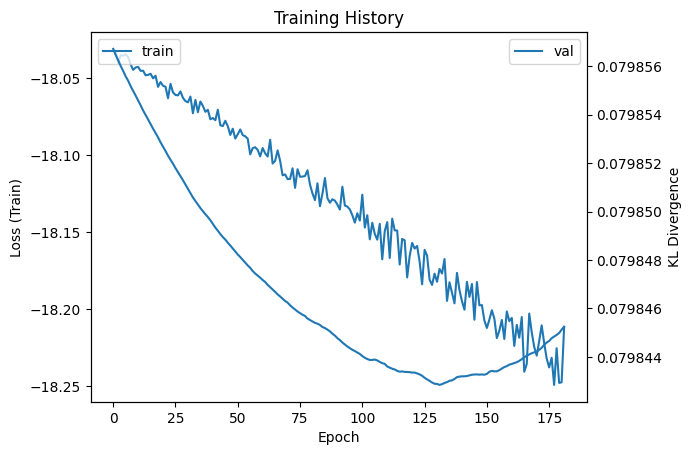

In [51]:
model, history = fit_best_model('EDL', 'SJAFFE', 1)
plot_history(history)

## Shut down the pool

In [46]:
executor.shutdown(wait=True, kill_workers=True)